                        Date      City     CO  CO2   NO2  SO2    O3  PM2.5  \
0  2024-01-01 00:00:00+00:00  Brasilia  323.0  NaN  23.8  2.8  42.0   12.0   
1  2024-01-01 01:00:00+00:00  Brasilia  318.0  NaN  21.9  2.7  40.0   12.5   
2  2024-01-01 02:00:00+00:00  Brasilia  309.0  NaN  19.2  2.6  39.0   12.1   
3  2024-01-01 03:00:00+00:00  Brasilia  295.0  NaN  16.3  2.4  38.0   11.4   
4  2024-01-01 04:00:00+00:00  Brasilia  270.0  NaN  13.0  2.1  40.0   10.2   

   PM10        AQI  
0  17.1  16.800000  
1  17.9  16.000000  
2  17.3  15.599999  
3  16.2  15.200000  
4  14.6  16.000000  
<class 'pandas.DataFrame'>
RangeIndex: 52704 entries, 0 to 52703
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    52704 non-null  str    
 1   City    52704 non-null  str    
 2   CO      52704 non-null  float64
 3   CO2     9648 non-null   float64
 4   NO2     52704 non-null  float64
 5   SO2     52704 non-null  float64
 6   O3    

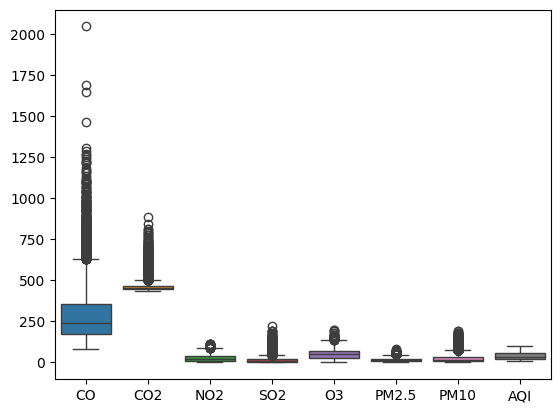

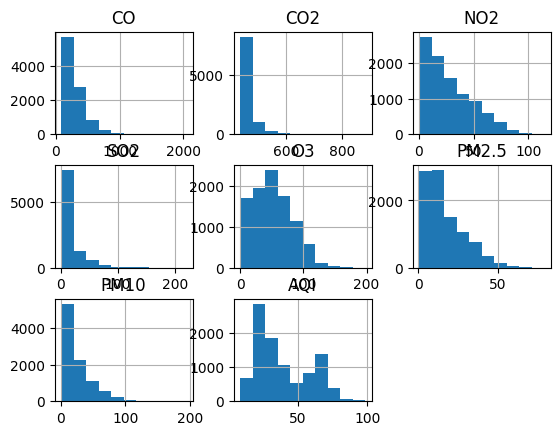

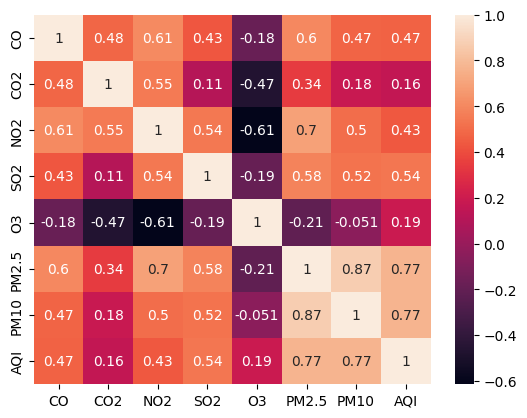

Custom Prediction: [26.22157324]
MSE: 89.81686786113514
R2 Score: 0.7596975078959297


In [3]:
# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset
df = pd.read_csv("Air_Quality.csv")

# 3. Basic Info
print(df.head())
print(df.info())
print(df.describe())

# 4. Data Preprocessing

# Drop unnecessary columns
df = df.drop(['Date', 'City'], axis=1)

# Handle missing values
df = df.dropna()

# 5. Data Analysis

# Boxplot (Outliers)
plt.figure()
sns.boxplot(data=df)
plt.show()

# Histogram
df.hist()
plt.show()

# Correlation Heatmap
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.show()

# 6. Model Building

# Features and Target
X = df.drop('AQI', axis=1)
y = df['AQI']

# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Custom Input Prediction
sample = X.iloc[0:1]
print("Custom Prediction:", model.predict(sample))

# 7. Evaluation

from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))